In [1]:
from pathlib import Path
import json
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import pyxdf

DATA_DIR = Path("data")
XDF_FILES = sorted(DATA_DIR.glob("*.xdf"))

print(f"Found {len(XDF_FILES)} XDF file(s) in {DATA_DIR.resolve()}")
for path in XDF_FILES:
    print("-", path.name)

Found 1 XDF file(s) in C:\Users\NML\Documents\Github\sEMG-model\sEMG_sleeve\data
- sub-001_ses-001_task-emg2angles_run-001_meg.xdf


In [2]:
def _flatten_info_dict(obj, prefix=""):
    flat = {}
    if isinstance(obj, dict):
        for key, value in obj.items():
            child_prefix = f"{prefix}.{key}" if prefix else str(key)
            flat.update(_flatten_info_dict(value, child_prefix))
    elif isinstance(obj, list):
        if len(obj) == 1:
            flat.update(_flatten_info_dict(obj[0], prefix))
        else:
            flat[prefix] = obj
    else:
        flat[prefix] = obj
    return flat


def _safe_shape(values):
    arr = np.asarray(values)
    return tuple(arr.shape), str(arr.dtype)


def _parse_xml_text(xml_text):
    if not xml_text:
        return None
    try:
        root = ET.fromstring(xml_text)
        return ET.tostring(root, encoding="unicode")[:1000]
    except ET.ParseError:
        return xml_text[:1000]


def summarize_xdf(path: Path):
    streams, header = pyxdf.load_xdf(str(path))
    rows = []
    detailed = []

    for idx, stream in enumerate(streams):
        info = stream.get("info", {})
        info_flat = _flatten_info_dict(info)
        time_series = stream.get("time_series", [])
        time_stamps = np.asarray(stream.get("time_stamps", []))
        series_shape, series_dtype = _safe_shape(time_series)
        nominal_srate = info_flat.get("nominal_srate")

        rows.append(
            {
                "stream_ix": idx,
                "name": info_flat.get("name"),
                "type": info_flat.get("type"),
                "channel_count": info_flat.get("channel_count"),
                "nominal_srate": nominal_srate,
                "samples": int(len(time_stamps)),
                "time_series_shape": series_shape,
                "time_series_dtype": series_dtype,
                "first_ts": float(time_stamps[0]) if len(time_stamps) else np.nan,
                "last_ts": float(time_stamps[-1]) if len(time_stamps) else np.nan,
                "duration_s": float(time_stamps[-1] - time_stamps[0]) if len(time_stamps) > 1 else np.nan,
            }
        )

        detailed.append(
            {
                "stream_ix": idx,
                "info": info_flat,
                "desc_preview": _parse_xml_text(info_flat.get("desc")),
                "first_sample": np.asarray(time_series[0]).tolist() if len(time_series) else None,
            }
        )

    return header, pd.DataFrame(rows), detailed

In [3]:
if not XDF_FILES:
    raise FileNotFoundError(f"No .xdf files found in {DATA_DIR.resolve()}")

xdf_path = XDF_FILES[0]
raw_streams, header = pyxdf.load_xdf(str(xdf_path))
header, summary_df, detailed_streams = summarize_xdf(xdf_path)

print(f"Inspecting: {xdf_path.name}")
print("\nHeader keys:", list(header.keys()))
summary_df

Inspecting: sub-001_ses-001_task-emg2angles_run-001_meg.xdf

Header keys: ['info']


,stream_ix,name,type,channel_count,nominal_srate,samples,time_series_shape,time_series_dtype,first_ts,last_ts,duration_s
0,0,StereoHandTracker_Angles,MOCAP,28,0.000000000000000,4856,"(4856, 28)",float32,764316.468724,764675.143915,358.675191
1,1,StereoHandTracker_Landmarks,MOCAP,126,0.000000000000000,4856,"(4856, 126)",float32,764316.466776,764675.141537,358.674761
2,2,OpenEphys_EMG,EMG,128,2000.000000000000,723968,"(723968, 128)",float32,764316.331657,764678.315164,361.983508


In [4]:
for stream in detailed_streams:
    print("=" * 100)
    print(f"Stream {stream['stream_ix']}")
    print(json.dumps(stream["info"], indent=2, default=str)[:4000])
    if stream["desc_preview"]:
        print("\nDescription preview:")
        print(stream["desc_preview"])
    print("\nFirst sample preview:")
    print(stream["first_sample"])

Stream 0
{
  "name": "StereoHandTracker_Angles",
  "type": "MOCAP",
  "channel_count": "28",
  "channel_format": "float32",
  "source_id": "hand_tracker_01_ang",
  "nominal_srate": "0.000000000000000",
  "version": "1.100000000000000",
  "created_at": "762361.7119156000",
  "uid": "0fabe256-ee15-4c85-b6f3-4a117ea8ef75",
  "session_id": "default",
  "hostname": "NML-HAPTICS",
  "v4address": null,
  "v4data_port": "16573",
  "v4service_port": "16573",
  "v6address": null,
  "v6data_port": "16573",
  "v6service_port": "16573",
  "desc": null,
  "stream_id": 1,
  "effective_srate": 0,
  "segments": [
    0,
    4855
  ],
  "clock_segments": [
    0,
    4855
  ]
}

First sample preview:
[23.668317794799805, 30.62460708618164, 80.68882751464844, 40.41334533691406, 31.150676727294922, 84.7805404663086, 105.56934356689453, 131.46060180664062, 83.15734100341797, 56.754642486572266, 61.170265197753906, 71.83133697509766, 48.39543533325195, 111.94271850585938, nan, nan, nan, nan, nan, nan, nan, 

In [5]:
# Optional: inspect a small numeric preview for each stream
for _, stream_row in summary_df.iterrows():
    print("=" * 100)
    print(f"Numeric preview for stream {stream_row['stream_ix']} ({stream_row['name']})")
    ts = np.asarray(raw_streams[stream_row['stream_ix']]['time_series'])
    if ts.ndim == 1:
        display(pd.Series(ts[:10], name="value"))
    elif ts.ndim >= 2:
        preview = pd.DataFrame(ts[:5])
        display(preview)
    else:
        print("No numeric preview available")

Numeric preview for stream 0 (StereoHandTracker_Angles)


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,23.668318,30.624607,80.688828,40.413345,31.150677,84.780540,105.569344,131.460602,83.157341,56.754642,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22.395153,29.237486,77.533066,43.655975,29.523197,84.231049,88.749657,119.672058,82.960510,41.085655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20.467775,25.409208,70.257378,42.337170,23.478304,77.991386,68.781891,104.270744,77.232040,30.556860,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18.508562,21.514950,62.319443,37.044708,21.325687,69.815620,50.045235,87.596252,69.392570,23.556591,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,16.948318,18.106171,55.376686,30.905394,21.224350,62.202698,36.525532,71.345398,62.086796,18.665602,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Numeric preview for stream 1 (StereoHandTracker_Landmarks)


,0,1,2,3,4,5,6,7,8,9,...,116,117,118,119,120,121,122,123,124,125
0,-0.131460,0.076944,0.618830,-0.146015,0.053179,0.597574,-0.160873,0.040287,0.567857,-0.166086,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.117029,0.074977,0.632846,-0.131392,0.049564,0.609276,-0.148552,0.034912,0.578599,-0.159036,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.102162,0.073160,0.643752,-0.116042,0.047274,0.618952,-0.134397,0.031683,0.587283,-0.147677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.088457,0.072287,0.652004,-0.101485,0.046028,0.626888,-0.120483,0.029685,0.594656,-0.135189,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.076747,0.071757,0.659446,-0.089688,0.045204,0.634276,-0.108754,0.028193,0.601773,-0.124399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Numeric preview for stream 2 (OpenEphys_EMG)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,148.675705,-153.175949,-94.029030,-37.397911,40.489594,33.655701,34.007999,-22.546585,27.374765,32.809029,...,10.091597,1.143908,4.548726,0.879338,0.639863,-4.916953,-9.330914,-12.267631,19.320744,7.340097
1,115.547913,-166.893768,-108.377937,-38.697975,41.526234,35.666420,34.037666,-9.592409,30.699299,35.134079,...,10.679516,0.921908,5.940710,1.558168,4.103190,-1.019009,-4.465325,-5.306197,26.507532,9.895883
2,110.585785,-167.229324,-119.833405,-33.643486,34.630871,31.219629,26.657162,3.170776,28.415543,27.508640,...,11.980216,0.926135,7.425619,4.936184,4.739416,2.501447,0.228715,0.516705,30.388247,14.481046
3,155.948975,-146.293884,-85.959518,-8.490108,24.442038,19.582636,17.400051,-2.060000,21.060047,17.224945,...,10.238969,-0.687778,8.193621,5.442602,4.758595,2.003889,-0.614395,1.841659,30.913830,13.722701
4,200.735901,-95.190758,-36.251358,55.266239,15.850063,9.937632,11.892812,-18.364967,15.970876,16.279680,...,5.799891,-3.327314,6.894263,0.856643,2.341788,-0.506573,-3.337354,0.604525,29.651869,5.823459


## Raw stream alignment checks

These cells visualize the native timestamps directly, without resampling or synchronization, so you can see how the EMG and mocap streams line up in recorded time.

In [6]:
import matplotlib.pyplot as plt


def _get_stream_by_name(name):
    for stream in raw_streams:
        if stream.get("info", {}).get("name", [None])[0] == name:
            return stream
    raise KeyError(f"Stream not found: {name}")


def _first_finite_column(arr):
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 1:
        return 0
    for col in range(arr.shape[1]):
        if np.isfinite(arr[:, col]).any():
            return col
    raise ValueError("No finite columns found")


angles_stream = _get_stream_by_name("StereoHandTracker_Angles")
landmarks_stream = _get_stream_by_name("StereoHandTracker_Landmarks")
emg_stream = _get_stream_by_name("OpenEphys_EMG")

angles_ts = np.asarray(angles_stream["time_stamps"], dtype=np.float64)
landmarks_ts = np.asarray(landmarks_stream["time_stamps"], dtype=np.float64)
emg_ts = np.asarray(emg_stream["time_stamps"], dtype=np.float64)

angles_x = np.asarray(angles_stream["time_series"], dtype=np.float32)
landmarks_x = np.asarray(landmarks_stream["time_series"], dtype=np.float32)
emg_x = np.asarray(emg_stream["time_series"], dtype=np.float32)

common_t0 = min(angles_ts[0], landmarks_ts[0], emg_ts[0])

stream_alignment_df = pd.DataFrame(
    [
        {
            "stream": "StereoHandTracker_Angles",
            "samples": len(angles_ts),
            "start_s": float(angles_ts[0] - common_t0),
            "end_s": float(angles_ts[-1] - common_t0),
            "duration_s": float(angles_ts[-1] - angles_ts[0]),
            "median_dt_ms": float(np.median(np.diff(angles_ts)) * 1000.0),
        },
        {
            "stream": "StereoHandTracker_Landmarks",
            "samples": len(landmarks_ts),
            "start_s": float(landmarks_ts[0] - common_t0),
            "end_s": float(landmarks_ts[-1] - common_t0),
            "duration_s": float(landmarks_ts[-1] - landmarks_ts[0]),
            "median_dt_ms": float(np.median(np.diff(landmarks_ts)) * 1000.0),
        },
        {
            "stream": "OpenEphys_EMG",
            "samples": len(emg_ts),
            "start_s": float(emg_ts[0] - common_t0),
            "end_s": float(emg_ts[-1] - common_t0),
            "duration_s": float(emg_ts[-1] - emg_ts[0]),
            "median_dt_ms": float(np.median(np.diff(emg_ts)) * 1000.0),
        },
    ]
)

stream_alignment_df

,stream,samples,start_s,end_s,duration_s,median_dt_ms
0,StereoHandTracker_Angles,4856,0.137067,358.812258,358.675191,73.678899
1,StereoHandTracker_Landmarks,4856,0.135120,358.809881,358.674761,74.192701
2,OpenEphys_EMG,723968,0.000000,361.983508,361.983508,0.500000


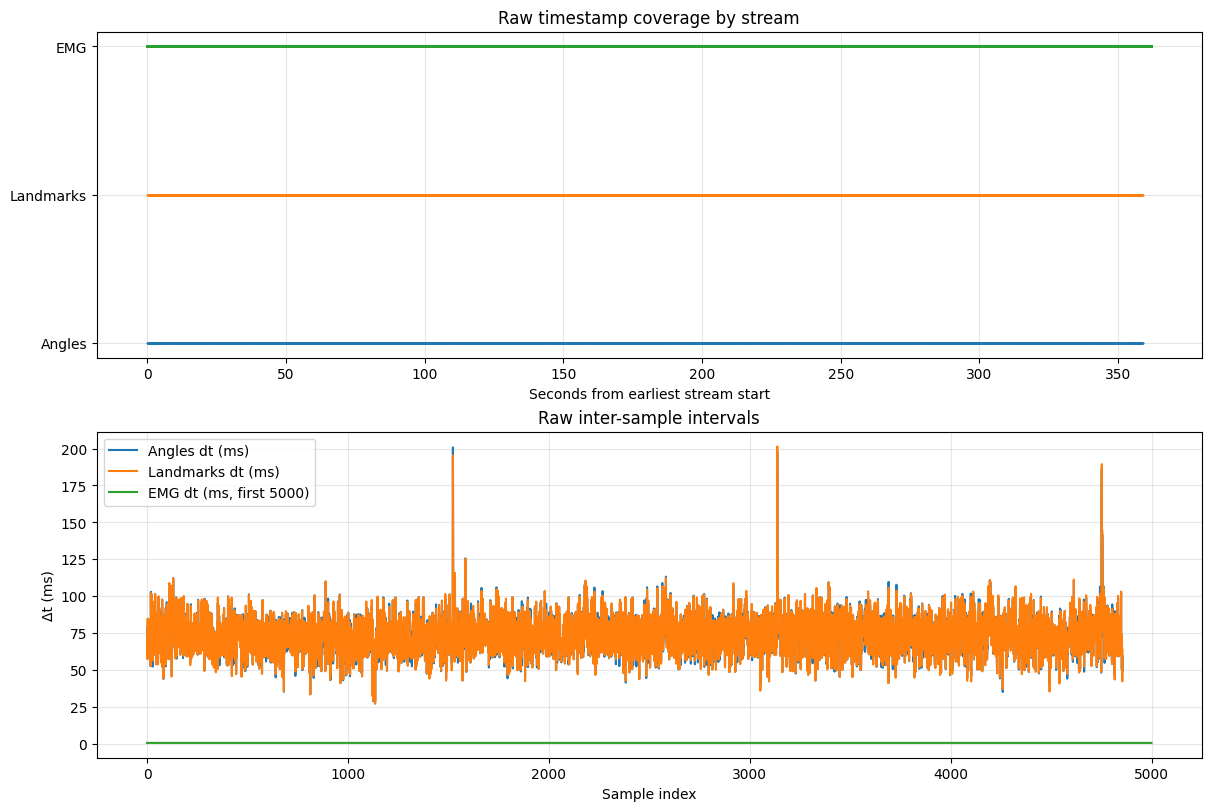

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

# Coverage over absolute recorded time
for i, (label, ts) in enumerate([
    ("Angles", angles_ts),
    ("Landmarks", landmarks_ts),
    ("EMG", emg_ts),
]):
    axes[0].plot(ts - common_t0, np.full_like(ts, i, dtype=float), ".", markersize=1, label=label)

axes[0].set_title("Raw timestamp coverage by stream")
axes[0].set_xlabel("Seconds from earliest stream start")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Angles", "Landmarks", "EMG"])
axes[0].grid(True, alpha=0.3)

# Inter-sample spacing without any synchronization
axes[1].plot(np.diff(angles_ts) * 1000.0, label="Angles dt (ms)")
axes[1].plot(np.diff(landmarks_ts) * 1000.0, label="Landmarks dt (ms)")
axes[1].plot(np.diff(emg_ts[:5000]) * 1000.0, label="EMG dt (ms, first 5000)")
axes[1].set_title("Raw inter-sample intervals")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Δt (ms)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()

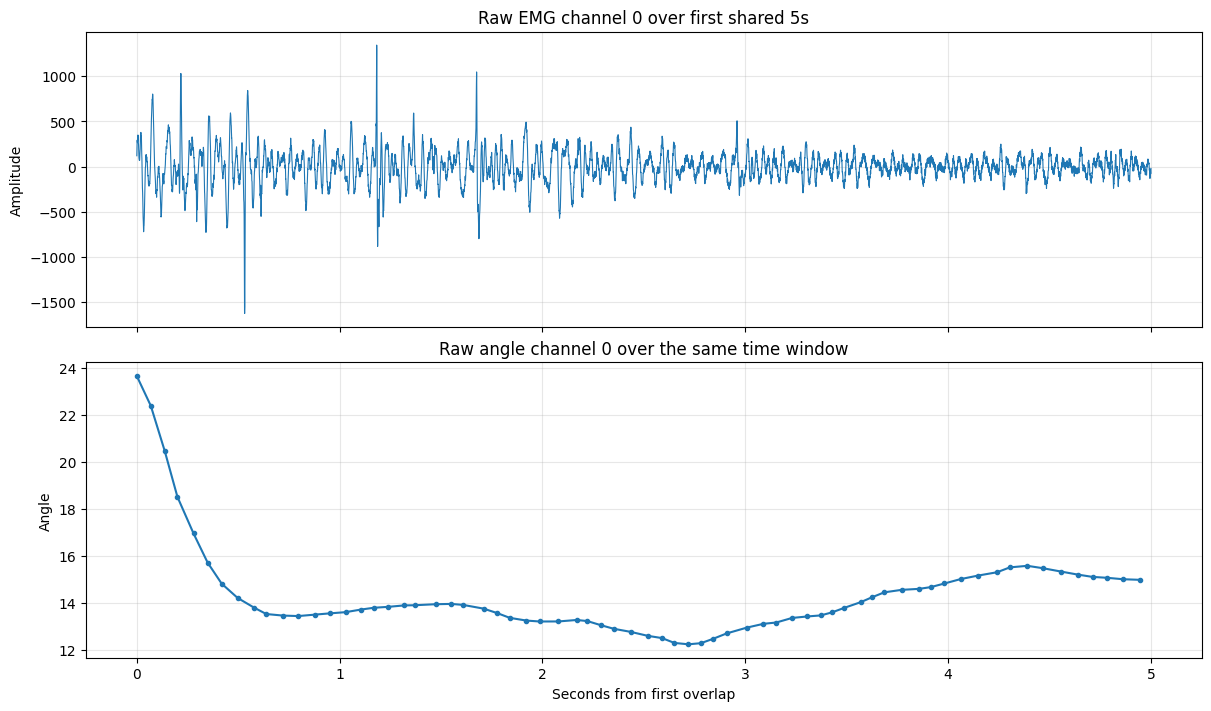

Using angle column 0 and EMG channel 0
This is a raw timestamp overlay only; no resampling, filtering, or alignment has been applied.


In [ ]:
angle_col = _first_finite_column(angles_x)
emg_col = 0

# Small raw overlap view with native timestamps only
window_start = max(angles_ts[0], emg_ts[0])
window_duration = 5.0
window_end = window_start + window_duration

angle_mask = (angles_ts >= window_start) & (angles_ts <= window_end)
emg_mask = (emg_ts >= window_start) & (emg_ts <= window_end)

angle_trace = angles_x[angle_mask, angle_col]
emg_trace = emg_x[emg_mask, emg_col]
angle_time = angles_ts[angle_mask] - window_start
emg_time = emg_ts[emg_mask] - window_start

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(emg_time, emg_trace, linewidth=0.8)
axes[0].set_title(f"Raw EMG channel {emg_col} over first shared {window_duration:.0f}s")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(angle_time, angle_trace, "o-", markersize=3)
axes[1].set_title(f"Raw angle channel {angle_col} over the same time window")
axes[1].set_xlabel("Seconds from first overlap")
axes[1].set_ylabel("Angle")
axes[1].grid(True, alpha=0.3)

plt.show()

print(f"Using angle column {angle_col} and EMG channel {emg_col}")

In [9]:
from scipy.signal import butter, filtfilt


def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    return butter(order, [low, high], btype="band")


def butter_lowpass(cutoff, fs, order=2):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    return butter(order, normal_cutoff, btype="low")


def interpolate_targets_to_emg(target_ts, target_x, emg_ts):
    target_ts = np.asarray(target_ts, dtype=np.float64)
    target_x = np.asarray(target_x, dtype=np.float64)
    emg_ts = np.asarray(emg_ts, dtype=np.float64)

    out = np.full((len(emg_ts), target_x.shape[1]), np.nan, dtype=np.float32)
    for col in range(target_x.shape[1]):
        y = target_x[:, col]
        valid = np.isfinite(target_ts) & np.isfinite(y)
        if np.count_nonzero(valid) < 2:
            continue
        out[:, col] = np.interp(emg_ts, target_ts[valid], y[valid]).astype(np.float32)
    return out

In [10]:
shared_start = max(angles_ts[0], emg_ts[0])
shared_end = min(angles_ts[-1], emg_ts[-1])

shared_emg_mask = (emg_ts >= shared_start) & (emg_ts <= shared_end)
shared_angle_mask = (angles_ts >= shared_start) & (angles_ts <= shared_end)
shared_landmark_mask = (landmarks_ts >= shared_start) & (landmarks_ts <= shared_end)

emg_ts_shared = emg_ts[shared_emg_mask]
emg_x_shared = emg_x[shared_emg_mask]
angles_ts_shared = angles_ts[shared_angle_mask]
angles_x_shared = angles_x[shared_angle_mask]
landmarks_ts_shared = landmarks_ts[shared_landmark_mask]
landmarks_x_shared = landmarks_x[shared_landmark_mask]

nan_fraction_angles = np.mean(~np.isfinite(angles_x_shared), axis=0)
nan_fraction_landmarks = np.mean(~np.isfinite(landmarks_x_shared), axis=0)

shared_summary = pd.DataFrame(
    {
        "stream": ["EMG", "Angles", "Landmarks"],
        "samples": [len(emg_ts_shared), len(angles_ts_shared), len(landmarks_ts_shared)],
        "start_s": [0.0, float(angles_ts_shared[0] - shared_start), float(landmarks_ts_shared[0] - shared_start)],
        "end_s": [float(emg_ts_shared[-1] - shared_start), float(angles_ts_shared[-1] - shared_start), float(landmarks_ts_shared[-1] - shared_start)],
        "duration_s": [float(emg_ts_shared[-1] - emg_ts_shared[0]), float(angles_ts_shared[-1] - angles_ts_shared[0]), float(landmarks_ts_shared[-1] - landmarks_ts_shared[0])],
    }
)

print(f"Shared overlap: {shared_end - shared_start:.3f} s")
print(f"Angle columns with any NaNs: {(nan_fraction_angles > 0).sum()} / {angles_x_shared.shape[1]}")
print(f"Landmark columns with any NaNs: {(nan_fraction_landmarks > 0).sum()} / {landmarks_x_shared.shape[1]}")
shared_summary

Shared overlap: 358.675 s
Angle columns with any NaNs: 14 / 28
Landmark columns with any NaNs: 63 / 126


,stream,samples,start_s,end_s,duration_s
0,EMG,717350,0.000000,358.674940,358.674508
1,Angles,4856,0.000000,358.675191,358.675191
2,Landmarks,4855,0.066129,358.672813,358.606685


In [11]:
angles_on_emg = interpolate_targets_to_emg(angles_ts_shared, angles_x_shared, emg_ts_shared)

# Optional low-pass smoothing on targets, analogous to Ninapro glove preprocessing
angles_on_emg_smooth = angles_on_emg.copy()
valid_angle_cols = np.where(np.isfinite(angles_on_emg).all(axis=0))[0]
if len(valid_angle_cols) > 0:
    b_lp, a_lp = butter_lowpass(cutoff=5.0, fs=2000.0, order=2)
    angles_on_emg_smooth[:, valid_angle_cols] = filtfilt(
        b_lp, a_lp, angles_on_emg[:, valid_angle_cols], axis=0
    ).astype(np.float32)

print("Interpolated angle array shape:", angles_on_emg.shape)
print("Fully finite interpolated angle columns:", int(np.isfinite(angles_on_emg).all(axis=0).sum()), "/", angles_on_emg.shape[1])
print("Fully finite smoothed angle columns:", int(np.isfinite(angles_on_emg_smooth).all(axis=0).sum()), "/", angles_on_emg_smooth.shape[1])

Interpolated angle array shape: (717350, 28)
Fully finite interpolated angle columns: 14 / 28
Fully finite smoothed angle columns: 14 / 28


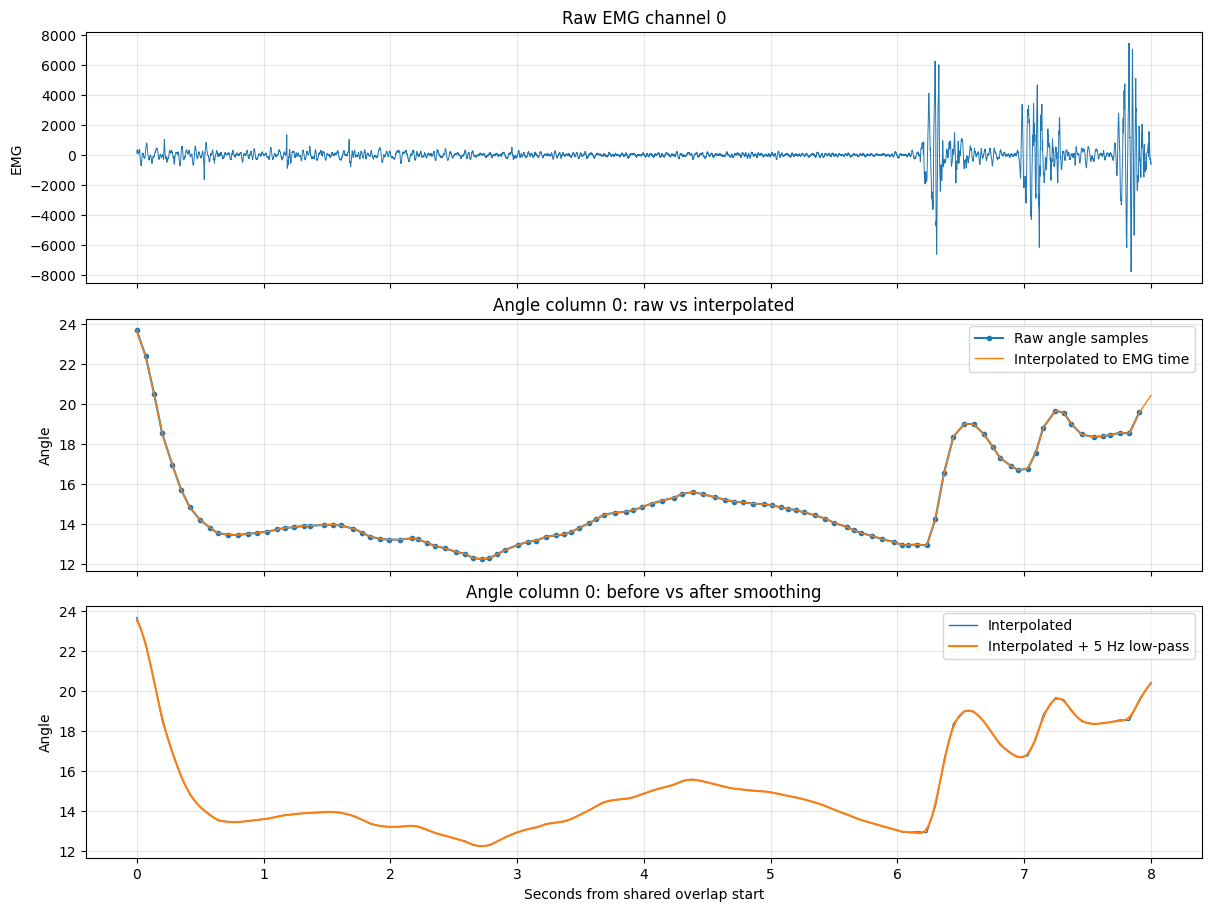

In [12]:
plot_col = angle_col
plot_start = 0.0
plot_duration = 8.0
plot_end = plot_start + plot_duration

angles_rel = angles_ts_shared - shared_start
emg_rel = emg_ts_shared - shared_start
plot_angle_mask = (angles_rel >= plot_start) & (angles_rel <= plot_end)
plot_emg_mask = (emg_rel >= plot_start) & (emg_rel <= plot_end)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
axes[0].plot(emg_rel[plot_emg_mask], emg_x_shared[plot_emg_mask, emg_col], linewidth=0.7)
axes[0].set_title(f"Raw EMG channel {emg_col}")
axes[0].set_ylabel("EMG")
axes[0].grid(True, alpha=0.3)

axes[1].plot(angles_rel[plot_angle_mask], angles_x_shared[plot_angle_mask, plot_col], "o-", markersize=3, label="Raw angle samples")
axes[1].plot(emg_rel[plot_emg_mask], angles_on_emg[plot_emg_mask, plot_col], linewidth=1.0, label="Interpolated to EMG time")
axes[1].set_title(f"Angle column {plot_col}: raw vs interpolated")
axes[1].set_ylabel("Angle")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(emg_rel[plot_emg_mask], angles_on_emg[plot_emg_mask, plot_col], linewidth=1.0, label="Interpolated")
axes[2].plot(emg_rel[plot_emg_mask], angles_on_emg_smooth[plot_emg_mask, plot_col], linewidth=1.5, label="Interpolated + 5 Hz low-pass")
axes[2].set_title(f"Angle column {plot_col}: before vs after smoothing")
axes[2].set_xlabel("Seconds from shared overlap start")
axes[2].set_ylabel("Angle")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.show()

In [13]:
win_len = 400
step_len = 100

n_windows = (len(emg_x_shared) - win_len) // step_len
window_emg = np.zeros((n_windows, emg_x_shared.shape[1], win_len), dtype=np.float32)
window_angles = np.zeros((n_windows, angles_on_emg_smooth.shape[1]), dtype=np.float32)
window_center_time = np.zeros(n_windows, dtype=np.float64)

for i in range(n_windows):
    start = i * step_len
    end = start + win_len
    center = start + (win_len // 2)
    window_emg[i] = emg_x_shared[start:end].T
    window_angles[i] = angles_on_emg_smooth[center]
    window_center_time[i] = emg_ts_shared[center]

window_summary = pd.DataFrame(
    {
        "n_windows": [n_windows],
        "window_len": [win_len],
        "step_len": [step_len],
        "window_emg_shape": [window_emg.shape],
        "window_angles_shape": [window_angles.shape],
        "window_duration_ms": [win_len / 2000.0 * 1000.0],
        "step_duration_ms": [step_len / 2000.0 * 1000.0],
    }
)

window_summary

,n_windows,window_len,step_len,window_emg_shape,window_angles_shape,window_duration_ms,step_duration_ms
0,7169,400,100,"(7169, 128, 400)","(7169, 28)",200.0,50.0


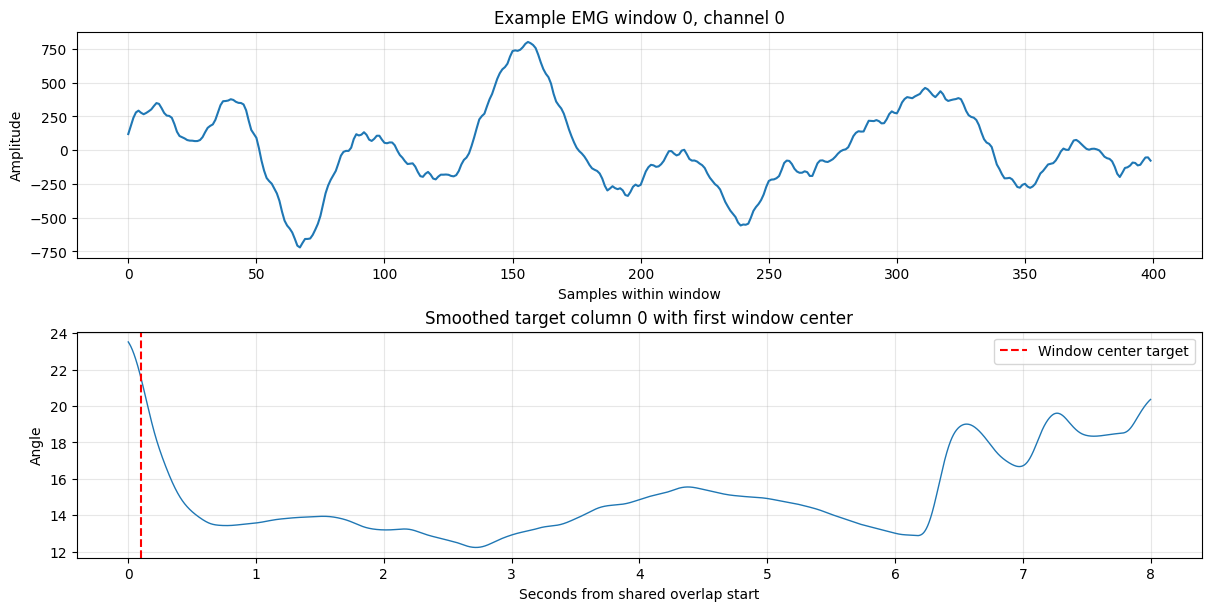

First window target value: 21.522380828857422


In [14]:
example_window = 0
example_channel = emg_col
example_target_col = plot_col

fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].plot(window_emg[example_window, example_channel])
axes[0].set_title(f"Example EMG window {example_window}, channel {example_channel}")
axes[0].set_xlabel("Samples within window")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(emg_rel[: 8 * 2000], angles_on_emg_smooth[: 8 * 2000, example_target_col], linewidth=1.0)
axes[1].axvline(window_center_time[example_window] - shared_start, color="r", linestyle="--", label="Window center target")
axes[1].set_title(f"Smoothed target column {example_target_col} with first window center")
axes[1].set_xlabel("Seconds from shared overlap start")
axes[1].set_ylabel("Angle")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.show()

print("First window target value:", float(window_angles[example_window, example_target_col]))

In [15]:
angle_info_flat = _flatten_info_dict(angles_stream.get("info", {}))
angle_info_series = pd.Series(angle_info_flat).sort_index()
print(angle_info_series.to_string())

angle_desc = angles_stream.get("info", {}).get("desc", [])
print("\nRaw desc object preview:")
print(str(angle_desc)[:4000])

print("\nAngle data shape:", angles_x.shape)
print("Finite columns:", int(np.isfinite(angles_x).all(axis=0).sum()), "/", angles_x.shape[1])
print("Columns with any values:", int(np.isfinite(angles_x).any(axis=0).sum()), "/", angles_x.shape[1])

channel_count                                        28
channel_format                                  float32
clock_segments                                (0, 4855)
created_at                            762361.7119156000
desc                                               None
effective_srate                                       0
hostname                                    NML-HAPTICS
name                           StereoHandTracker_Angles
nominal_srate                         0.000000000000000
segments                                      (0, 4855)
session_id                                      default
source_id                           hand_tracker_01_ang
stream_id                                             1
type                                              MOCAP
uid                0fabe256-ee15-4c85-b6f3-4a117ea8ef75
v4address                                          None
v4data_port                                       16573
v4service_port                                  